## 1. Imports & Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
    classification_report, ConfusionMatrixDisplay
)

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("All libraries loaded successfully ✓")


All libraries loaded successfully ✓


## 2. Load the Dataset

In [ ]:
# ── adjust path as needed ──
df = pd.read_csv("diabetes.csv")

print(f"Dataset shape : {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(10)


Dataset shape : (768, 9)  (768 rows × 9 columns)
Memory usage  : 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Exploratory Data Analysis (EDA)


### 3.1 Data Types & Basic Info

In [ ]:
print("=" * 50)
print("COLUMN INFO")
print("=" * 50)
df.info()
print()
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])


COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


### 3.2 Missing Values & Biologically Implausible Zeros

In [ ]:
# Null check
print("Explicit NaN values:", df.isnull().sum().sum())

# Columns where 0 is biologically impossible
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_summary = pd.DataFrame({
    'Zero Count'  : [(df[c] == 0).sum() for c in zero_cols],
    'Zero %'      : [(df[c] == 0).mean() * 100 for c in zero_cols]
}, index=zero_cols)
print()
print("Implausible zeros (encoded missing values):")
print(zero_summary.to_string())


Explicit NaN values: 0

Implausible zeros (encoded missing values):
               Zero Count     Zero %
Glucose                 5   0.651042
BloodPressure          35   4.557292
SkinThickness         227  29.557292
Insulin               374  48.697917
BMI                    11   1.432292


In [ ]:
df_clean = df.copy()

for col in zero_cols:
    median_val = df_clean.loc[df_clean[col] != 0, col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("Zero imputation complete ✓")
print()
print(df_clean[zero_cols].describe().T[['mean','std','min','max']])


Zero imputation complete ✓

                     mean        std   min    max
Glucose        121.656250  30.438286  44.0  199.0
BloodPressure   72.386719  12.096642  24.0  122.0
SkinThickness   29.108073   8.791221   7.0   99.0
Insulin        140.671875  86.383060  14.0  846.0
BMI             32.455208   6.875177  18.2   67.1


### 3.3 Target Class Distribution

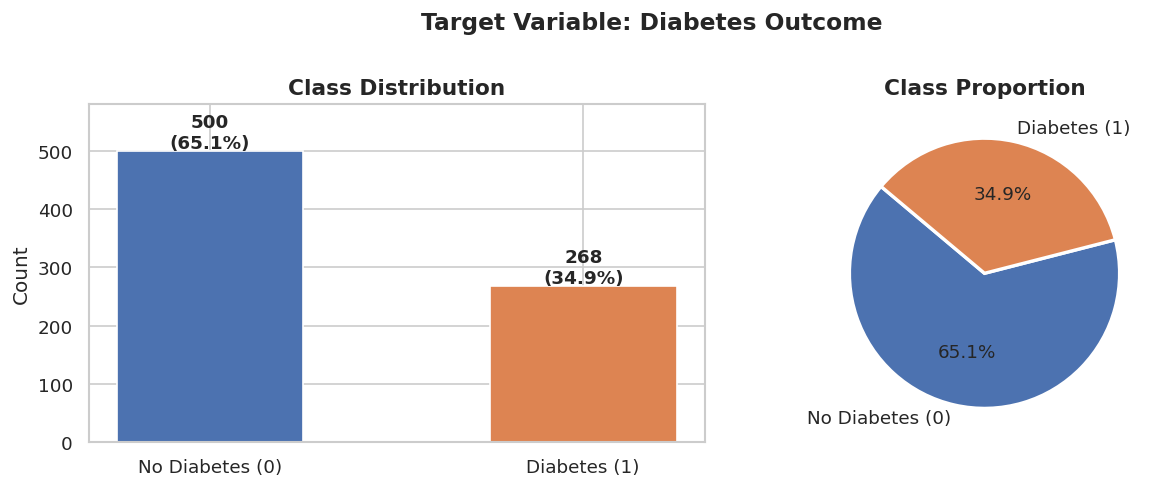


Class imbalance ratio  →  Non-diabetic : Diabetic = 500:268 (1.87:1)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
counts = df_clean['Outcome'].value_counts()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['#4C72B0', '#DD8452']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df_clean)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 580)

# Pie
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Diabetes Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nClass imbalance ratio  →  Non-diabetic : Diabetic = {counts[0]}:{counts[1]} ({counts[0]/counts[1]:.2f}:1)")


### 3.4 Feature Distributions by Outcome

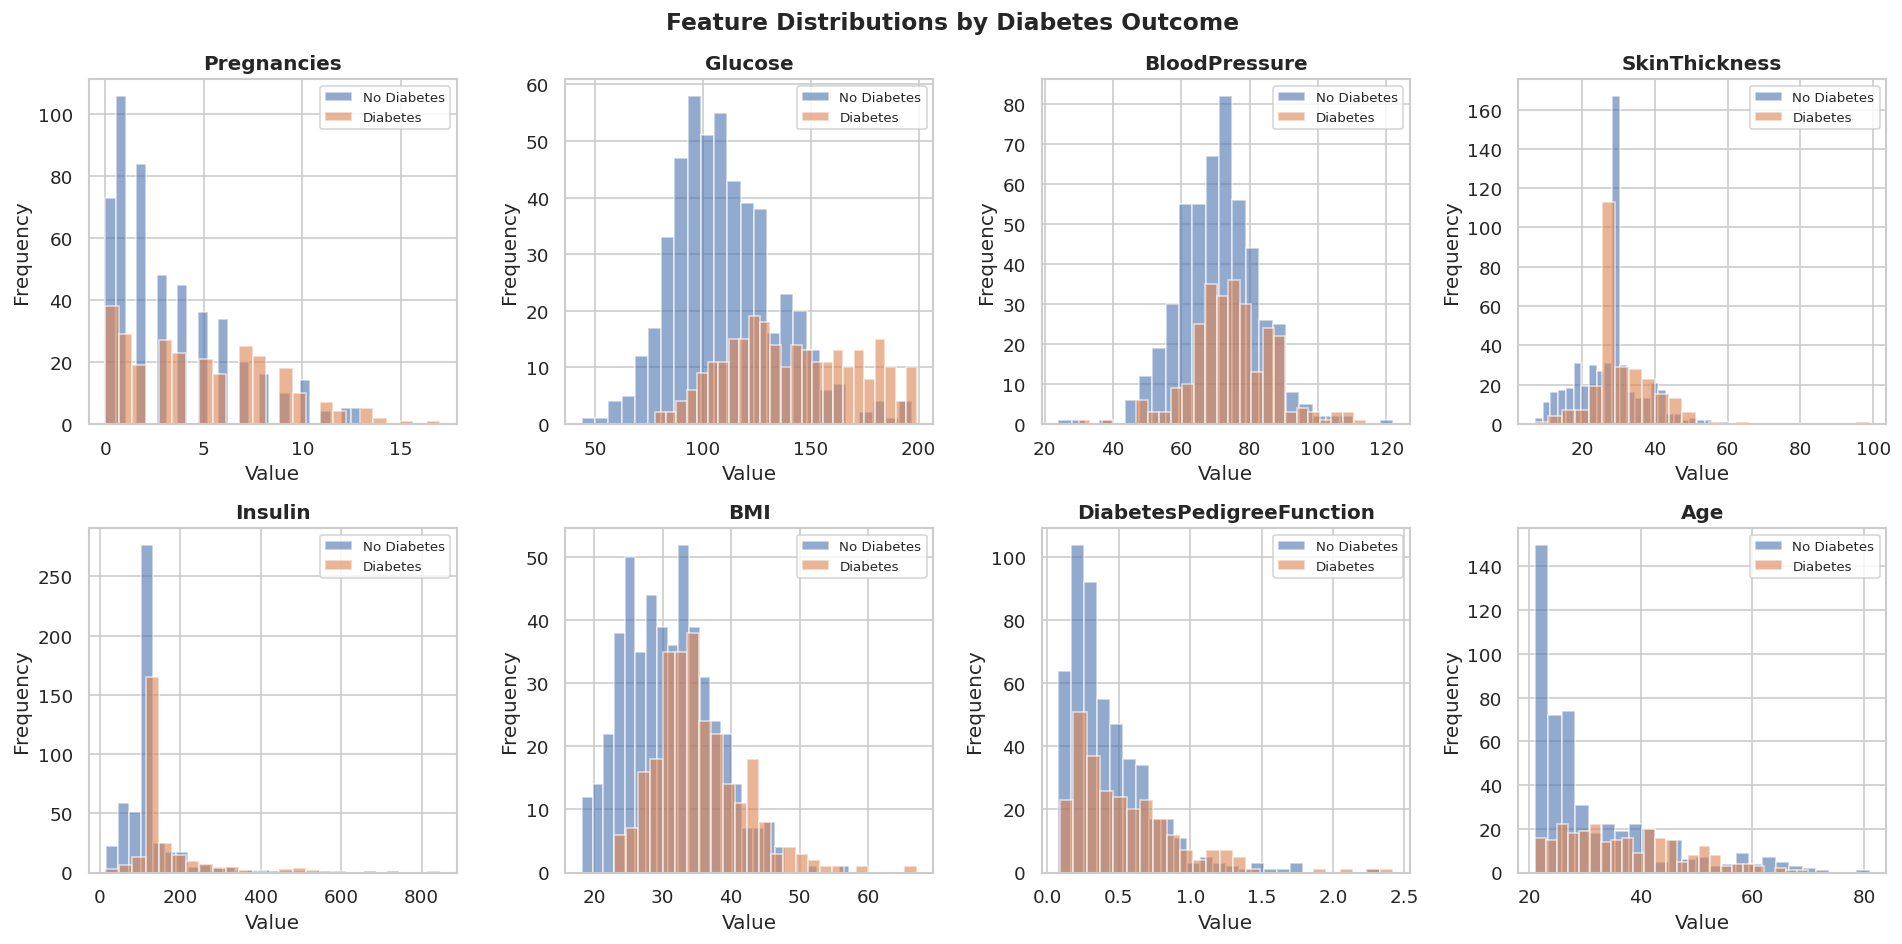

In [ ]:
features = [c for c in df_clean.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0,'#4C72B0','No Diabetes'), (1,'#DD8452','Diabetes')]:
        subset = df_clean[df_clean['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.6 Correlation Heatmap

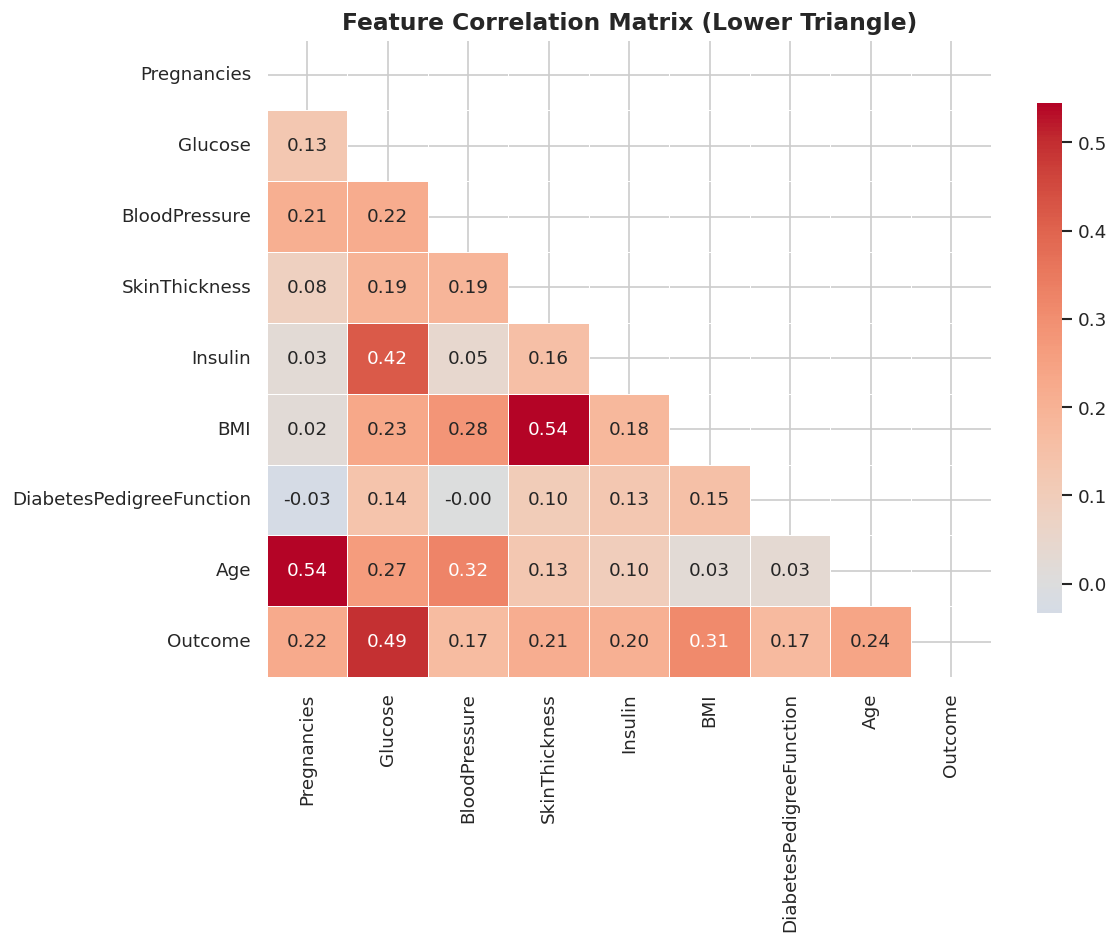


Top feature correlations with Outcome:
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723


In [ ]:
corr = df_clean.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))    # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Outcome
print("\nTop feature correlations with Outcome:")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).to_string())


### 3.7 Pairplot — Multivariate Relationships

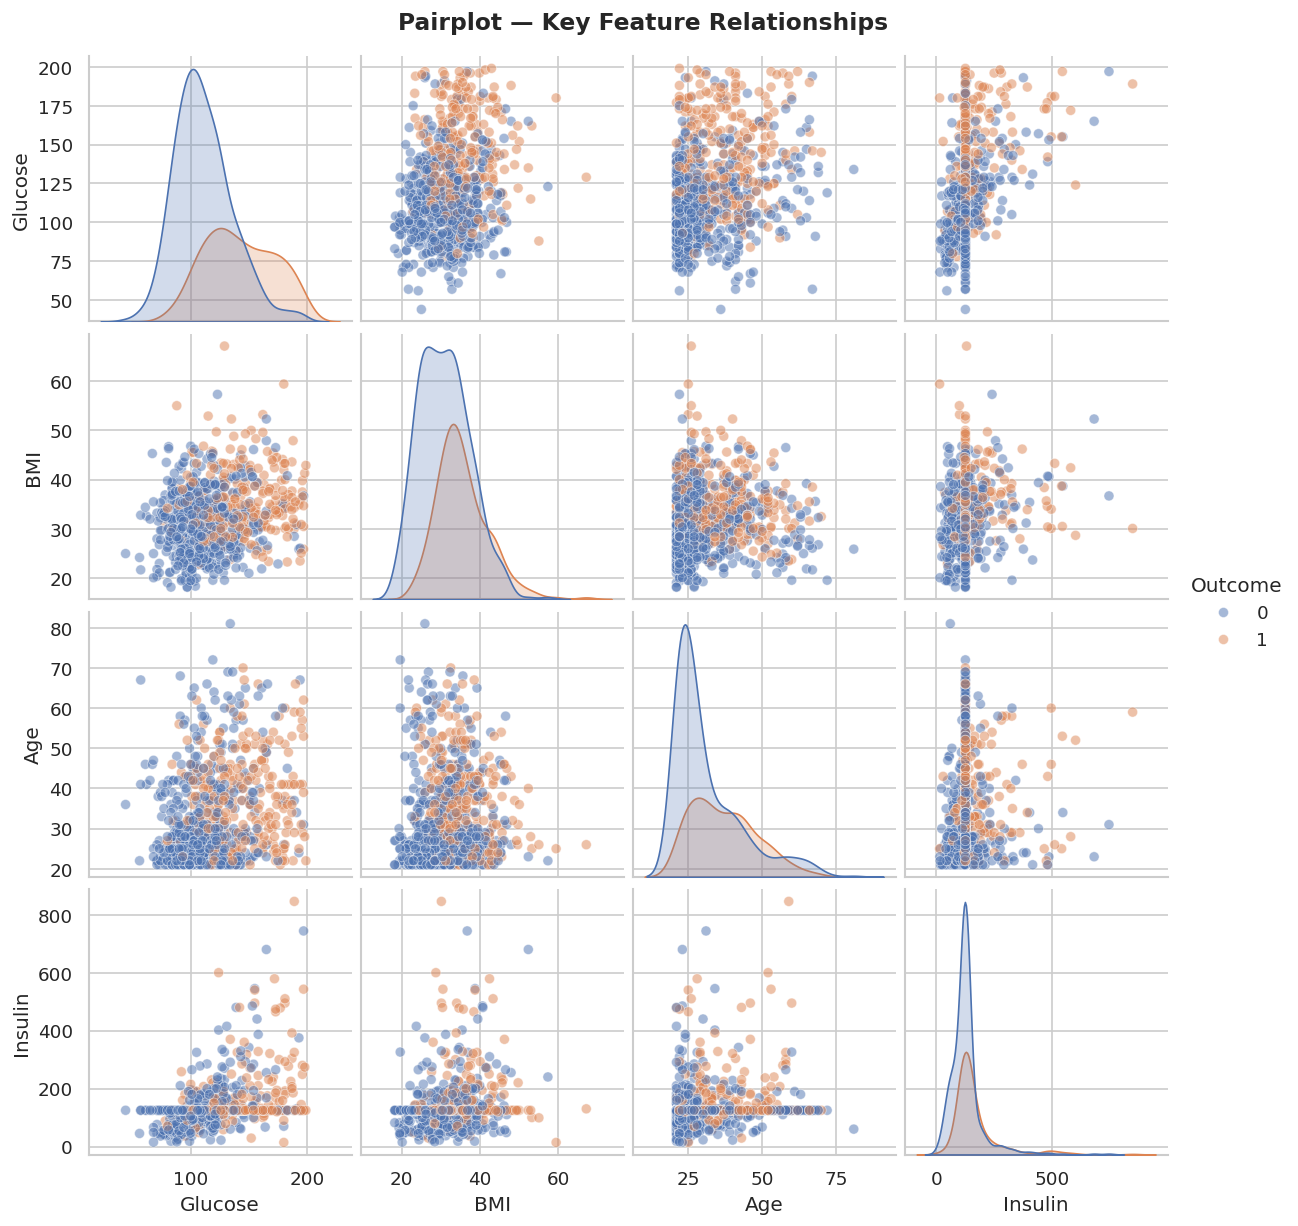

In [ ]:
# Subset most discriminative features to keep the plot readable
subset_feats = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
g = sns.pairplot(df_clean[subset_feats], hue='Outcome',
                 palette={0:'#4C72B0', 1:'#DD8452'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pairplot — Key Feature Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## 4. Algorithm Suitability Assessment (ILO2)

Before building our primary model we compare three classifiers across four criteria:

| Criterion | Logistic Regression | Decision Tree | **Random Forest** |
|---|---|---|---|
| Handles non-linearity | ✗ | ✓ | ✓ |
| Robust to outliers | Moderate | Low | **High** |
| Risk of overfitting | Low | High | **Low** |
| Interpretability | High | High | Moderate |
| Computational cost | Very Low | Low | Moderate |

**Conclusion:** Random Forest is the most appropriate algorithm for this dataset because:
1. The features show non-linear separability (visible in pairplot).
2. Class imbalance (65/35) benefits from ensemble averaging.
3. Feature importance is readily extractable, preserving interpretability.


## 5. Data Pre-processing & Train/Test Split

In [ ]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Training set   : {X_train.shape[0]} samples  "
      f"(diabetic={y_train.sum()}, non-diabetic={len(y_train)-y_train.sum()})")
print(f"Test set       : {X_test.shape[0]} samples  "
      f"(diabetic={y_test.sum()}, non-diabetic={len(y_test)-y_test.sum()})")

# Scale features (needed for Logistic Regression baseline)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nStandardisation complete ✓")


Training set   : 537 samples  (diabetic=187, non-diabetic=350)
Test set       : 231 samples  (diabetic=81, non-diabetic=150)

Standardisation complete ✓


## 6. Model Training

In [ ]:
# ── Primary model ──
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ── Baseline models ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("All models trained ✓")


All models trained ✓


## 7. Model Evaluation

### 7.1 Core Metrics

In [ ]:
def evaluate(model, X_t, y_t, model_name):
    y_pred = model.predict(X_t)
    tn, fp, fn, tp = confusion_matrix(y_t, y_pred).ravel()
    return {
        'Model'      : model_name,
        'Accuracy'   : accuracy_score(y_t, y_pred),
        'Precision'  : precision_score(y_t, y_pred),
        'Recall'     : recall_score(y_t, y_pred),
        'Specificity': tn / (tn + fp),
        'F1-Score'   : f1_score(y_t, y_pred),
        'AUC-ROC'    : roc_auc_score(y_t, model.predict_proba(X_t)[:, 1])
    }

results = pd.DataFrame([
    evaluate(rf, X_test,    y_test, 'Random Forest'),
    evaluate(lr, X_test_sc, y_test, 'Logistic Regression'),
    evaluate(dt, X_test,    y_test, 'Decision Tree'),
])
results.set_index('Model', inplace=True)
results.round(4).style.background_gradient(cmap='Greens', axis=0)


,Accuracy,Precision,Recall,Specificity,F1-Score,AUC-ROC
Model,,,,,,
Random Forest,0.740300,0.666700,0.518500,0.860000,0.583300,0.815900
Logistic Regression,0.744600,0.671900,0.530900,0.860000,0.593100,0.836100
Decision Tree,0.692600,0.565800,0.530900,0.780000,0.547800,0.655400


### 7.2 Confusion Matrix — Random Forest

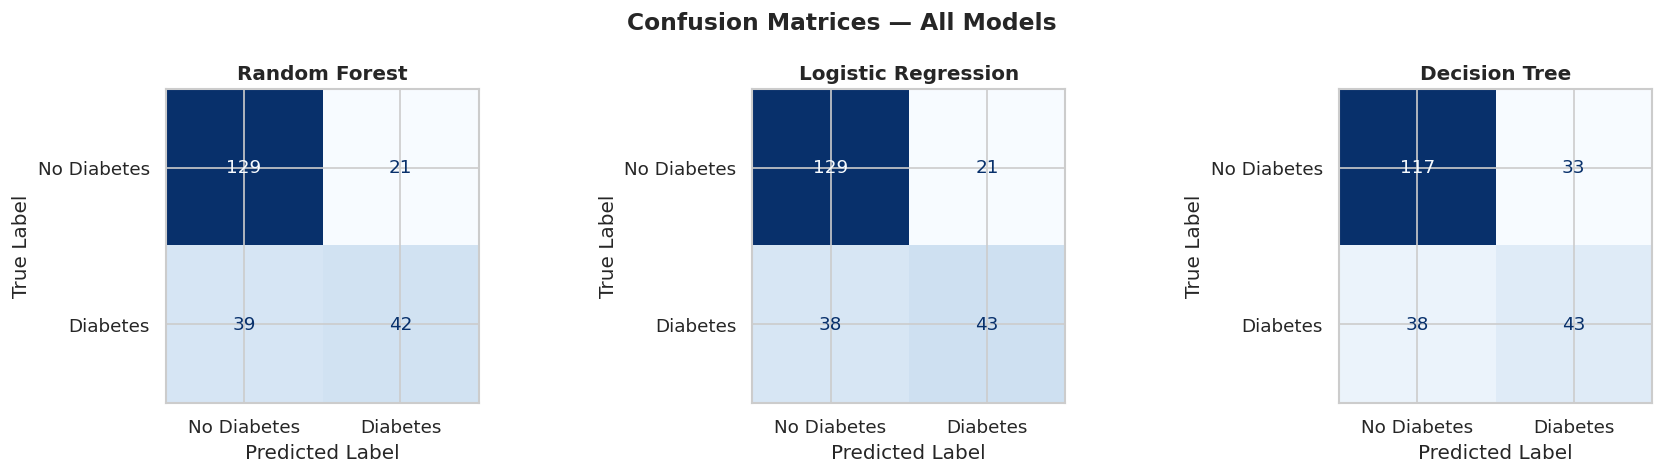

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_info = [
    (rf,  X_test,    'Random Forest'),
    (lr,  X_test_sc, 'Logistic Regression'),
    (dt,  X_test,    'Decision Tree'),
]

for ax, (model, Xt, name) in zip(axes, models_info):
    cm = confusion_matrix(y_test, model.predict(Xt))
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 ROC Curves

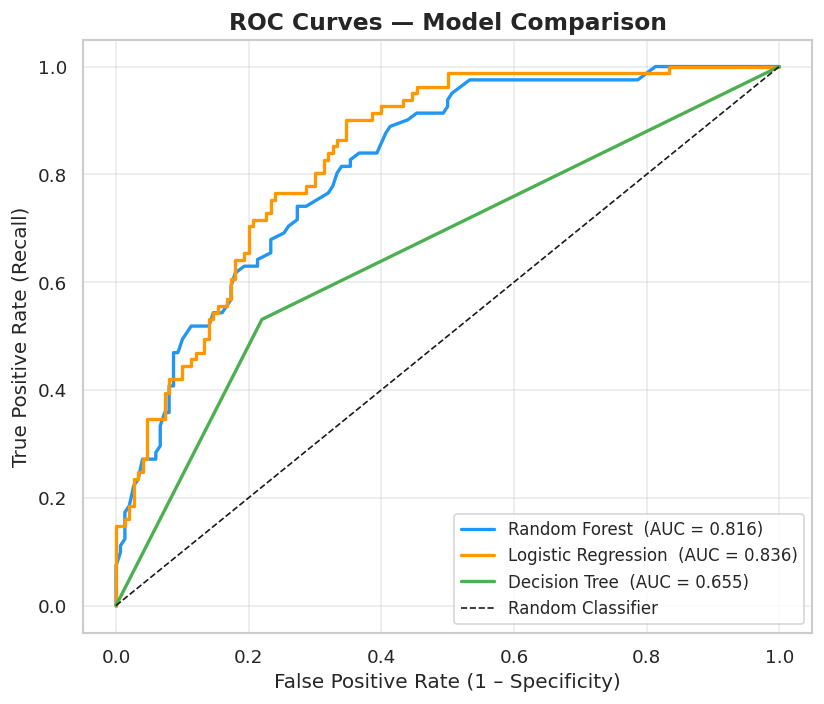

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for model, Xt, name, color in [
    (rf, X_test,    'Random Forest',       '#2196F3'),
    (lr, X_test_sc, 'Logistic Regression', '#FF9800'),
    (dt, X_test,    'Decision Tree',       '#4CAF50'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(Xt)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(Xt)[:, 1])
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### 7.4 Cross-Validation (Stratified 5-Fold)

Random Forest             CV Accuracy: 0.7538 ± 0.0265
Logistic Regression       CV Accuracy: 0.7734 ± 0.0156
Decision Tree             CV Accuracy: 0.7187 ± 0.0485


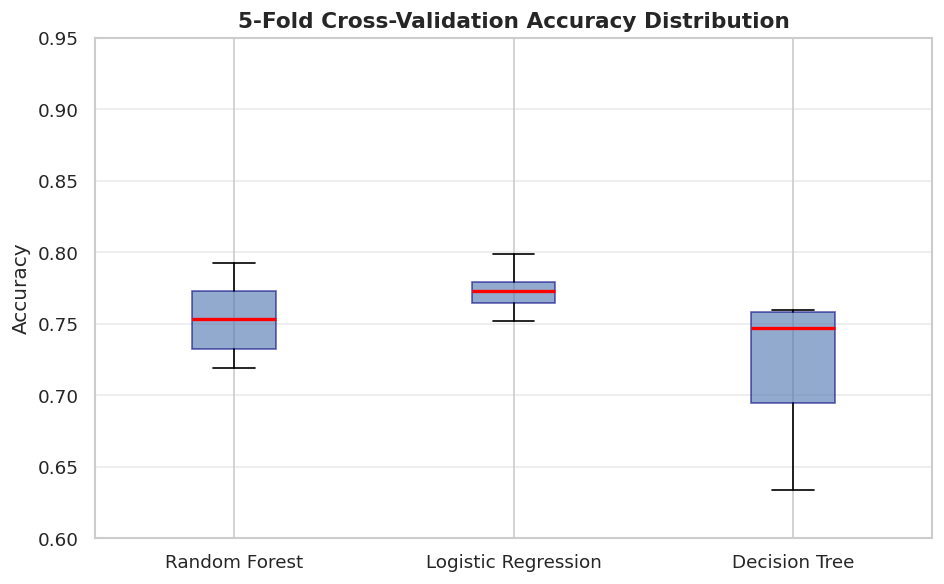

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for model, Xt, name in [
    (rf, X,    'Random Forest'),
    (lr, scaler.fit_transform(X), 'Logistic Regression'),
    (dt, X,    'Decision Tree'),
]:
    scores = cross_val_score(model, Xt, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<25} CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', color='navy', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('5-Fold Cross-Validation Accuracy Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.6, 0.95)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


### 7.5 Feature Importance

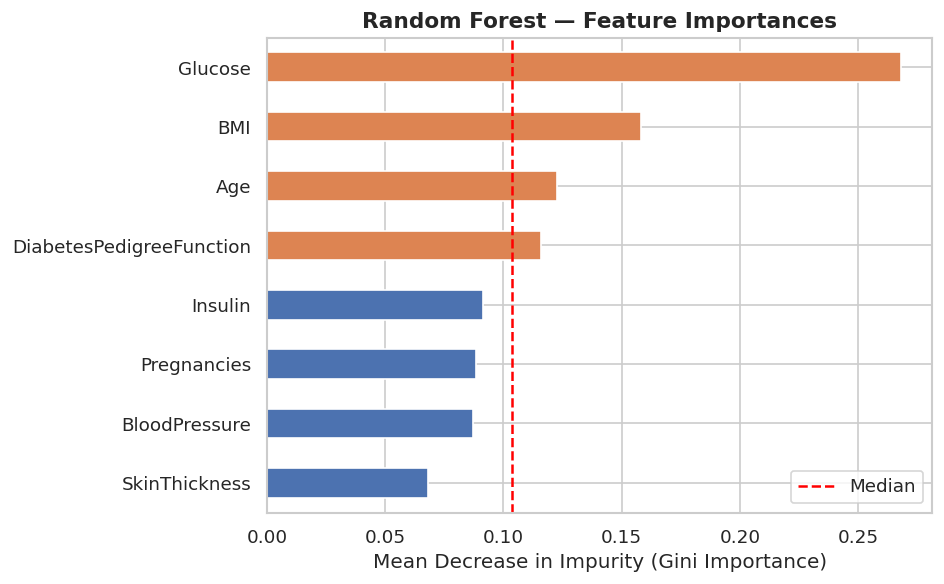


Feature importance ranking:
Glucose                     0.268015
BMI                         0.158051
Age                         0.122681
DiabetesPedigreeFunction    0.116073
Insulin                     0.091462
Pregnancies                 0.088386
BloodPressure               0.087170
SkinThickness               0.068162


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#DD8452' if v >= importances.median() else '#4C72B0' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)')
ax.axvline(importances.median(), color='red', linestyle='--', lw=1.5, label='Median')
ax.legend()
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
print(importances[::-1].to_string())


## 9. Full Classification Report — Random Forest

In [ ]:
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf,
      target_names=['No Diabetes', 'Diabetes']))


              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       150
    Diabetes       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231

